---
title: "HW-3: Pre-trained computer vision models"
author: "Jorge Bris Moreno"
format:
  html:
    embed-resources: true
---

# HW-3: Pre-trained computer vision models 

Author: J. Hickman

**Overview:**

* In deep learning we don't always have to train our neural networks from scratch
* Often "pre-trained models" exist which we can "pull of the shelf" and use as part of a data processing pipeline. 
* In this assignment, we will use the popular "You only look once" (YOLO) deep learning algorithm to do object detection.
  * https://pytorch.org/hub/ultralytics_yolov5/
* Assume you are working for a company interested in traffic patterns and driver behavior 
  * For example, a car-insurance company, a traffic data analytics firm, or a self driving car start-up 
* This company has "dash-camera" footage from various cars in their "fleet" 
* As an initial proof of concept they want you to write a code to track the locations of other vehicles from the recordings 
* They also want you to analyze the time-dependence of traffic patterns found in the videos.

**Submission:**

* You need to upload ONE document to Canvas when you are done
  * (1) A PDF (or HTML) of the completed form of the "HW-3.ipynb" document 
* The final uploaded version should NOT have any code-errors present 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

**Note**:

* There are many ways to do this assignment and the methods below are guidelines not rules.
* If you find more efficient ways to complete the objectives then feel free to do it however you want. 
* **IMPORTANT: START SMALL THEN SCALE UP** 
  * Get everything working for a simple case with a few images, once everything seems to be working correctly then run it on the entire data set

**Data source**:

* Dash cam footage: https://www.youtube.com/watch?v=9qy4lExIetk
* Website to download youtube videos: https://en.y2mate.is/67/



### Import

In [145]:
# Libraries
import torch
from IPython.display import Image
import matplotlib.pyplot as plt
import shutil 
import os
import cv2

print(torch.__version__)

2.2.1


#### Part-3.0 

Open the file "video-res-2.mp4" and watch a few minutes to get familiar with the content

#### Part-3.1: Pre-processing

* The video is 2hr8min55s which is 2*60*60+8*60+55=7735 seconds 
* The frame rate for the video is roughly 30 frames per second 
* So there are around 7735*30=232050 frames
* Write code to read and convert the video "video-res-2.mp4" into an ORDERED set of images 
* Include a parameter to save frames every N seconds 
* Don't save every frame, at first save frames every 50 seconds, that will be around 155 images
* Once everything is working, save frames every 10 seconds and re-run the code for the final product.
* Save the images to a folder "frames" with the convention 
  * "frames/00010.jpg" for the frame 10 seconds into the video
  * "frames/00020.jpg" for the frame 20 seconds into the video and so on


In [146]:
# For extra info

video_path = 'video-res-2.mp4'
vid = cv2.VideoCapture(video_path)

# get video info
fps = vid.get(cv2.CAP_PROP_FPS)
total_frames = vid.get(cv2.CAP_PROP_FRAME_COUNT)
duration = total_frames / fps
print(f'fps: {fps}, total_frames: {total_frames}, duration: {duration}')

fps: 29.97, total_frames: 231828.0, duration: 7735.335335335336


In [147]:
#INSERT CODE HERE 
# To obtain same output as the one in the question
print_intervals = [0, 50000, 100000, 150000, 200000]
print(vid.__class__)

for interval in print_intervals:
    print(interval)

vid.release()


<class 'cv2.VideoCapture'>
0
50000
100000
150000
200000


#### Part-3.2: Explore the model 

Before processing the video data, we want to make sure we can get YOLO working correctly for a few images

In [148]:
#INSERT CODE TO LOAD THE YOLO MODEL USING PYTORCH

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

Using cache found in /Users/jbm/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-3-16 Python-3.10.12 torch-2.2.1 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [149]:
# Function -> extract frames from a video
def get_frames(video_path, times, target_folder):

    # Load the video
    vid = cv2.VideoCapture(video_path)
    
    # Create frames list
    frames = []

    for t in times:
        frame_number = t*1000

        # Set the frame position based on the time (in seconds)
        vid.set(cv2.CAP_PROP_POS_MSEC, frame_number)
        
        # Read the frame
        success, image = vid.read()
        
        if success:
            # Set each file's name
            filename = f"{str(int(t)).zfill(5)}.jpg"
            # Set the save path
            save_path = os.path.join(target_folder, filename)

            # Save frame as JPEG
            cv2.imwrite(save_path, image)
            # Save images in the right path
            frames.append(save_path)
    
    # Release the video capture object
    vid.release()
    # return the frames (For checking the progress and that we are saving them all correctly)
    return frames


times = [50, 200]
target_folder = 'frames'

obtained_frames_paths = get_frames(video_path, times, target_folder)
obtained_frames_paths

['frames/00050.jpg', 'frames/00200.jpg']

In [150]:
# AT FIRST USE THE FOLLOWING IMAGES AS A TEST CASE
images=['frames/00050.jpg','frames/00200.jpg']  

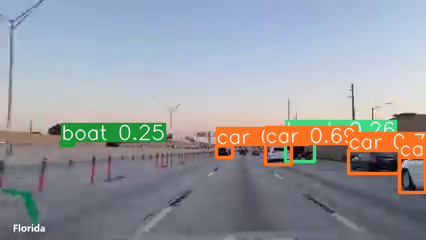

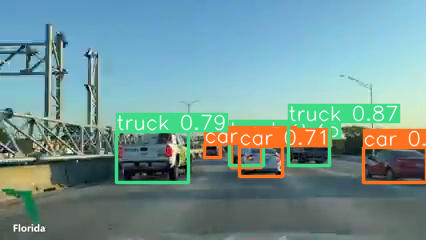

In [151]:
# INSERT CODE TO EVALUATE THE YOLO MODEL ON THESE IMAGES
results = model(images)
results.show()

In [152]:
# WHEN WORKING IN PYTHON WITH AN OBJECT OF AN UN-FAMILIAR CLASS IT IS 
# VERY USEFUL TO FIGURE OUT THE CLASSES ATTRIBUTES AND METHOD
print(type(results))

<class 'models.common.Detections'>


In [153]:
# INSERT CODE TO FIGURE OUT WHAT THE OBJECTS ATTRIBUTES OF THE "results" OBJECT ARE
print(results.__dict__.keys())

dict_keys(['ims', 'pred', 'names', 'files', 'times', 'xyxy', 'xywh', 'xyxyn', 'xywhn', 'n', 't', 's'])


In [154]:
#  INSERT CODE TO FIGURE OUT WHAT THE OBJECTS METHODS OF THE "results" OBJECT ARE
print([method for method in dir(results) if callable(getattr(results, method))])

['__class__', '__delattr__', '__dir__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '_run', 'crop', 'pandas', 'print', 'render', 'save', 'show', 'tolist']


In [155]:
# PRINT A SUMMARY OF THE RESULT
results.print()

image 1/2: 240x426 4 cars, 1 truck, 1 boat
image 2/2: 240x426 4 cars, 3 trucks
Speed: 4.3ms pre-process, 156.3ms inference, 1.3ms NMS per image at shape (2, 3, 384, 640)


In [156]:
#THE INFORMATION ABOUT THE BOUNDING BOXES CAN BE EXTRACTED AS FOLLOWS
print(results.pandas().xyxy[1])

         xmin        ymin        xmax        ymax  confidence  class   name
0  288.718414  122.997223  329.926331  165.041534    0.869563      7  truck
1  363.126007  147.772217  426.000000  182.583176    0.848963      2    car
2  116.674019  131.229599  188.073257  182.016342    0.793729      7  truck
3  239.904663  146.646088  282.098633  176.821854    0.714780      2    car
4  204.365540  144.626816  220.182419  157.711853    0.386479      2    car
5  229.952972  138.270065  263.365479  165.125015    0.349598      7  truck
6  231.498993  142.332169  261.764008  167.849060    0.269167      2    car


In [157]:
# INSERT CODE TO REMOVE THE FOLDER "runs" IF IT EXISTS THEN RUN "results.save()"
results.save()

Saved 2 images to runs/detect/exp16


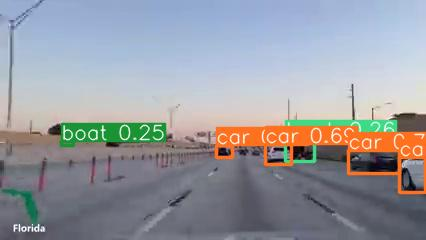

In [158]:
# LOOK AT THE FIRST IMAGE
Image("runs/detect/exp/00050.jpg")

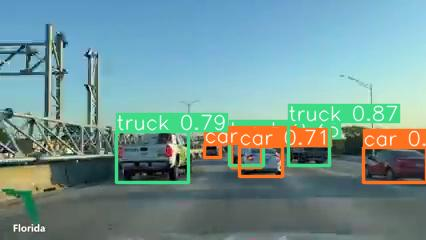

In [159]:
Image("runs/detect/exp/00200.jpg")

#### Part-3.3: Explore the results  

The following code will plot the image and add a vertical line roughly down the center of the car's hood

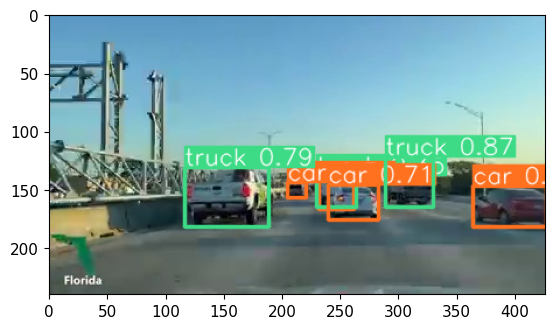

In [160]:
# Changed code slightly because it was not imgs but ims
%matplotlib inline
results.render()
plt.imshow(results.ims[1])
plt.show()

image 1/2: 240x426 4 cars, 1 truck, 1 boat
image 2/2: 240x426 4 cars, 3 trucks
Speed: 4.3ms pre-process, 156.3ms inference, 1.3ms NMS per image at shape (2, 3, 384, 640)


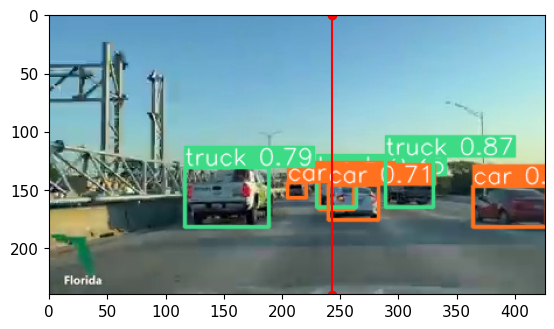

In [161]:
#PLOT IMAGE WITH REGIONAL SUB-DIVIDING LINES
def plot_lines(img):
    YMAX=img.shape[0]
    XMAX=img.shape[1]
    XCENTER=0.57*XMAX

    x1 = XCENTER; y1 = 0; x2 = XCENTER; y2 = YMAX 
    plt.plot([x1,x2], [y1,y2], marker = 'o',color="red")
    plt.imshow(img)
    plt.show()

results.print()
plot_lines(results.ims[1])



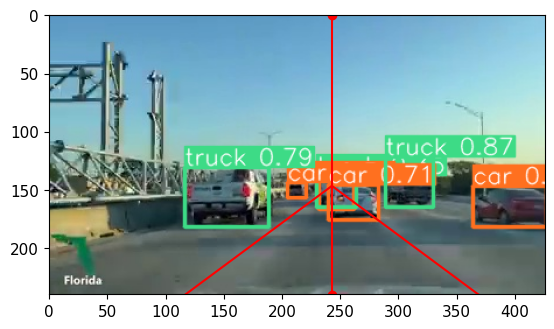

In [162]:
# INSERT CODE TO MODIFY THE FUNCTION TO GENERATE THE FOLLOWING IMAGE TO ROUGHLY ISOLATE THE LANE
# YOU CAN JUST USE GEOMETRY TO DO THIS

def plot_lane_lines(img):
    YMAX = img.shape[0]
    XMAX = img.shape[1]
    XCENTER = 0.57 * XMAX

    x1 = XCENTER; y1 = 0; x2 = XCENTER; y2 = YMAX
    plt.plot([x1, x2], [y1, y2], marker = 'o', color="red")
    
    # Diagonal Lines
    left_x1 = XCENTER * 0.48  
    left_y1 = YMAX
    left_x2 = XCENTER
    left_y2 = YMAX * 0.61 

    right_x1 = XCENTER * 1.52
    right_y1 = YMAX
    right_x2 = XCENTER
    right_y2 = YMAX * 0.61

    # Add the lines to the plot
    plt.plot([left_x1, left_x2], [left_y1, left_y2], color="red")
    plt.plot([right_x1, right_x2], [right_y1, right_y2], color="red")
    
    # Plot
    plt.imshow(img)
    plt.show()

# Call the plot function and display on the image
plot_lane_lines(results.ims[1])

Insert a function to output a modified version of the results.pandas().xyxy[i] data-frame in the following ways 

* normalize (scale) the xmin, xmax by the width of the image and ymin, ymax by the height --> HxW=1x1 
* compute the area and center of each box using the normalized coordinates
* add a column named "nearby" which is True if normalized_area>0.05
* **Optional**: Use The geometric lane construction from the previous image and the location of the box center to compute which lane (left,center,right) nearby vehicles are in
 
```
       xmin      ymin      xmax      ymax  confidence  ...   name nearby  \
0  0.677506  0.515625  0.771468  0.680202    0.859959  ...  truck  False   
1  0.831234  0.617149  0.977826  0.743249    0.851794  ...    car  False   
2  0.002621  0.457946  0.410202  0.926958    0.820941  ...  truck   True   
3  0.547734  0.598833  0.656238  0.750011    0.581989  ...    car  False   
4  0.473275  0.594087  0.518594  0.662508    0.503990  ...    car  False   

       area  x_center  y_center  
0  0.015464  0.724487  0.597913  
1  0.018485  0.904530  0.680199  
2  0.191160  0.206412  0.692452  
3  0.016403  0.601986  0.674422  
4  0.003101  0.495935  0.628297  
```

In [163]:
#INSERT CODE TO MODIFY THE DATAFRAME 
#TO INCLUDE THE COORDINATES OF THE LINES

def modified_dataframe(results, image_index):
    
    # Get the df
    df = results.pandas().xyxy[image_index]

    # Width and height of image
    width = results.ims[image_index].shape[1]
    height = results.ims[image_index].shape[0]
    
    # Normalized box coordinates
    df[['xmin', 'xmax']] /= width
    df[['ymin', 'ymax']] /= height

    # area of each box
    df['area'] = (df['xmax'] - df['xmin']) * (df['ymax'] - df['ymin'])

    # nearby
    df['nearby'] = df['area'] > 0.05

    # center of each box
    df['x_center'] = (df['xmin'] + df['xmax']) / 2
    df['y_center'] = (df['ymin'] + df['ymax']) / 2

    
    
    return df

modified_df = modified_dataframe(results, 1)
modified_df

,xmin,ymin,xmax,ymax,confidence,...,name,area,nearby,x_center,y_center
0,0.677743,0.512488,0.774475,0.687673,0.869563,...,truck,0.016946,False,0.726109,0.600081
1,0.852408,0.615718,1.000000,0.760763,0.848963,...,car,0.021408,False,0.926204,0.688240
2,0.273883,0.546790,0.441487,0.758401,0.793729,...,truck,0.035467,False,0.357685,0.652596
3,0.563156,0.611025,0.662203,0.736758,0.714780,...,car,0.012453,False,0.612680,0.673892
4,0.479731,0.602612,0.516860,0.657133,0.386479,...,car,0.002024,False,0.498296,0.629872
5,0.539796,0.576125,0.618229,0.688021,0.349598,...,truck,0.008776,False,0.579012,0.632073
6,0.543425,0.593051,0.614470,0.699371,0.269167,...,car,0.007553,False,0.578947,0.646211


### Part-3.4: Process all images

**Note:** Those warning do not affect the outputs, they are called from sklearn. Also we have print the first 10 paths for checking purposes.

In [164]:
# INSERT CODE TO FORM AN ORDERED (SORTED) LIST OF ALL IMAGES IN "frames" 
times = range(0, 7735, 10)

obtained_frames_paths = get_frames(video_path, times, target_folder)
obtained_frames_paths[:10]

[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure
[h264 @ 0x7f8f5d38b2c0] mmco: unref short failure


['frames/00000.jpg',
 'frames/00010.jpg',
 'frames/00020.jpg',
 'frames/00030.jpg',
 'frames/00040.jpg',
 'frames/00050.jpg',
 'frames/00060.jpg',
 'frames/00070.jpg',
 'frames/00080.jpg',
 'frames/00090.jpg']

In [165]:
# INSERT CODE TO RUN YOLO ON THE COMPLETE LIST

results = model(obtained_frames_paths)

In [166]:
results.save()

Saved 774 images to runs/detect/exp17


### Part-3.5: Time-series analysis 

Loop over the results and build arrays with time-series data for the following 
* The frames should be ordered so you can treat the index as a "time" variables
* Total number num_cars and num_trucks in each frame
* num_neighbor = Number of neighboring cars and trucks (use normalized box area > .05 to signify a nearby car or truck)

In [167]:
# 3.5.1: INSERT CODE TO LOOP OVER RESULTS AND BUILD ARRAYS

def overtime_frames(results):
    # create empty lists
    car = []
    truck = []
    nearby = []
    
    for i, df in enumerate(results.pandas().xyxy):
        # Normalize box coordinates and get the new area
        width = results.ims[i].shape[1]
        height = results.ims[i].shape[0]
        df['area'] = ((df['xmax'] - df['xmin']) / width) * ((df['ymax'] - df['ymin']) / height)
        df['nearby'] = df['area'] > 0.05
        
        # Total number of cars and trucks
        car.append((df['name'] == 'car').sum())
        truck.append((df['name'] == 'truck').sum())
        
        # Number of nearby vehicles
        nearby.append(df['nearby'].sum())
    
    return car, truck, nearby

# Obtaining the values
car, truck, nearby = overtime_frames(results)

# print the first 30 values of each type
print("CAR \n", car[:30])
print("TRUCK \n", truck[:30])
print("NEARBY \n",nearby[:30])


CAR 
 [0, 3, 0, 2, 1, 4, 4, 3, 5, 3, 6, 11, 4, 5, 9, 5, 6, 0, 1, 6, 4, 9, 4, 0, 3, 7, 2, 4, 5, 5]
TRUCK 
 [0, 0, 0, 3, 0, 1, 2, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 3, 0, 6, 1, 3, 1, 5, 3, 1, 1]
NEARBY 
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 2]


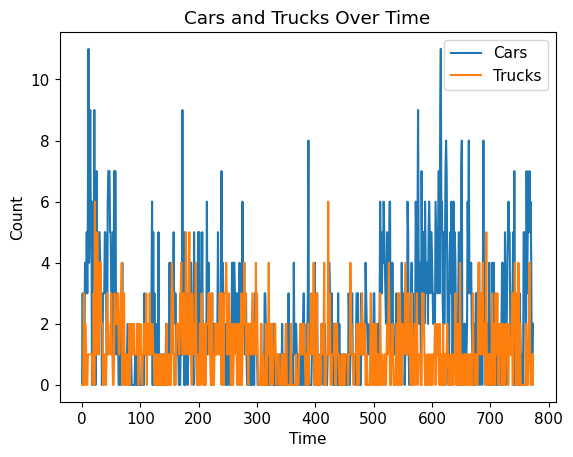

In [172]:
# INSERT CODE TO GENERATE THE FOLLOWING PLOT
plt.plot(car, label='Cars')
plt.plot(truck, label='Trucks')
plt.title('Cars and Trucks Over Time')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend()

Text(0, 0.5, 'Count')

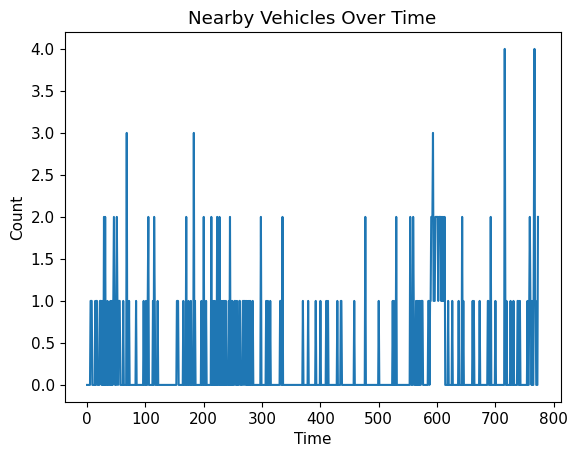

In [173]:
# INSERT CODE TO GENERATE THE FOLLOWING PLOT
plt.plot(nearby, label='Nearby vehicles')
plt.title('Nearby Vehicles Over Time')
plt.xlabel('Time')
plt.ylabel('Count')